In [1]:
# End-to-End Sales Data Analysis and Visualization

# By: Sumit  
# Tools: Python, Pandas, Matplotlib, Seaborn, Power BI


In [2]:
# importing libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# loading a dataset

df = pd.read_csv(r"C:\Users\Sumit\OneDrive\kaggledatasets\sales_data.csv")
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
# check basics data overview

df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

In [5]:
# checking missing values
df.isnull().sum()

# there are no missing value

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [6]:
# checking duplicates 
df.duplicated()

# there are no duplicates found

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [7]:
# checking datatypes
df.dtypes

Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object

In [8]:
# converting sale_date column object to datetime 

df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])
df["Sale_Date"].dtypes

dtype('<M8[ns]')

In [9]:
# “Column names were standardized by converting to lowercase and replacing spaces with underscores for better readability and consistency.”

df.columns = ["product_id", "sale_date", "sales_rep", "region",
              "sales_amount", "quantity_sold", "product_category",
              "unit_cost", "unit_price", "customer_type", "discount",
              "payment_method", "sales_channel", "region_and_sales_rep"]

# checking the columns was reanmed or not 
df.columns

Index(['product_id', 'sale_date', 'sales_rep', 'region', 'sales_amount',
       'quantity_sold', 'product_category', 'unit_cost', 'unit_price',
       'customer_type', 'discount', 'payment_method', 'sales_channel',
       'region_and_sales_rep'],
      dtype='object')

In [10]:
df.drop(columns=["region_and_sales_rep"], inplace=True)

# “The column region_and_sales_rep was removed as it was redundant, 
# since the same information was already available in separate columns (region and sales_rep).”

In [11]:
# creating a feature 

df["profit_per_unit"] = df["unit_price"] - df["unit_cost"]

df["total_profit"] = df["profit_per_unit"] * df["quantity_sold"]

df["month"] = df["sale_date"].dt.month
df["year"] = df["sale_date"].dt.year

# Feature engineering was performed to derive new metrics such as profit per unit and total profit. 
# These were recalculated to ensure accuracy after refining the logic.

In [12]:
# data analysis 
# top category by profit

category_profit = df.groupby("product_category")["total_profit"].sum().sort_values(ascending=False)

# insight - The Electronics category generates the highest total profit,
#           indicating strong profitability and demand in this segment.

In [13]:
# top sales representative

sales_rep_perf = df.groupby("sales_rep")[["sales_amount","total_profit"]].sum().sort_values(by="total_profit", ascending=False)

sales_rep_perf

# insight - David is the top-performing sales representative in terms of total profit
#           and charlie is lowest



,sales_amount,total_profit
sales_rep,,
David,1141737.36,1501749.76
Eve,970183.99,1449081.90
Alice,965541.77,1294822.01
Bob,1080990.63,1170800.24
Charlie,860811.48,1071393.16


In [14]:
# region performance

df.groupby("region")["total_profit"].sum().sort_values(ascending = False)

# insight - The North region generates the highest total profit, and  
#           the South region shows comparatively lower profit.

region
North    1661461.20
West     1656091.77
East     1650557.20
South    1519736.90
Name: total_profit, dtype: float64

In [15]:
# discount analysis
df.groupby("discount")[["sales_amount","total_profit"]].mean().sort_index()

# insight -  The analysis shows that increasing discounts does not consistently increase sales,
#            Moderate discount levels appear to provide a better balance between sales and profit.

,sales_amount,total_profit
discount,,
0.00,4511.495000,6302.830000
0.01,5103.344324,8122.763514
0.02,4435.165833,5130.542917
0.03,5604.861282,5333.697949
0.04,5234.551053,7027.368421
0.05,5741.821923,8032.342308
0.06,4432.347419,6978.728710
0.07,4599.938485,5924.158182
0.08,4967.657742,7413.122258


In [16]:
# customer behaviour
df.groupby(["customer_type", "payment_method"]).size()

# insight - New customers show a slight preference for Bank Transfer as the most used payment method,
#          while returning customers prefer Credit Card. 

customer_type  payment_method
New            Bank Transfer     181
               Cash              160
               Credit Card       163
Returning      Bank Transfer     161
               Cash              153
               Credit Card       182
dtype: int64

In [17]:
# time analysis

# monthly sales
df.groupby("month")["sales_amount"].sum()

# insight - : Sales show clear monthly fluctuations, with peak performance observed in January,
#             October, and November, while lower sales are recorded in February, 
#             July, and September. 


month
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: sales_amount, dtype: float64

In [18]:
# yearly sales

df.groupby("year")["sales_amount"].sum()

# insight -  The yearly sales data shows that the majority of transactions are from 2023,
#            while 2024 contains only a small portion of data.


year
2023    4999937.22
2024      19328.01
Name: sales_amount, dtype: float64

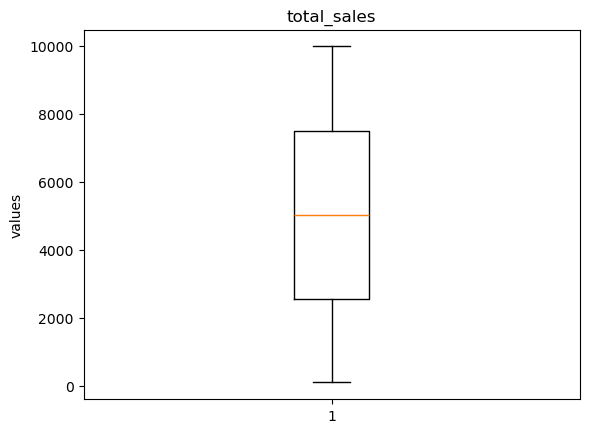

In [19]:
# finding outliers
x = df["sales_amount"]

plt.boxplot(x)
plt.ylabel("values")
plt.title("total_sales")
plt.show()

# insight -  Boxplot analysis shows that the dataset does not contain significant extreme outliers,
#            indicating a stable distribution of sales and profit values. 


<Axes: ylabel='total_profit'>

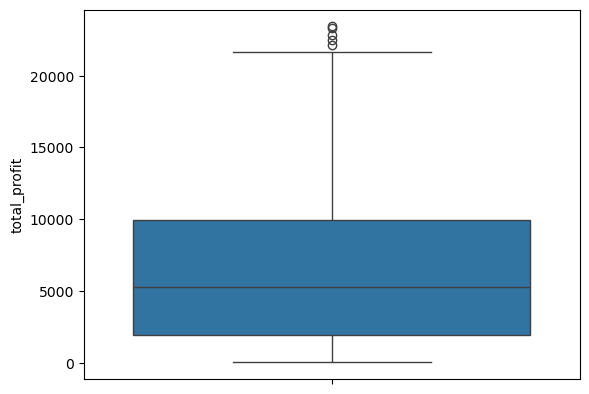

In [20]:
# boxplot for "total_profit" using seaborn 
y = df["total_profit"]
sns.boxplot(y)

# insight - Boxplot analysis reveals the presence of high-value outliers in total_profit, 
#            indicating some transactions generate significantly higher profit than the majority. 


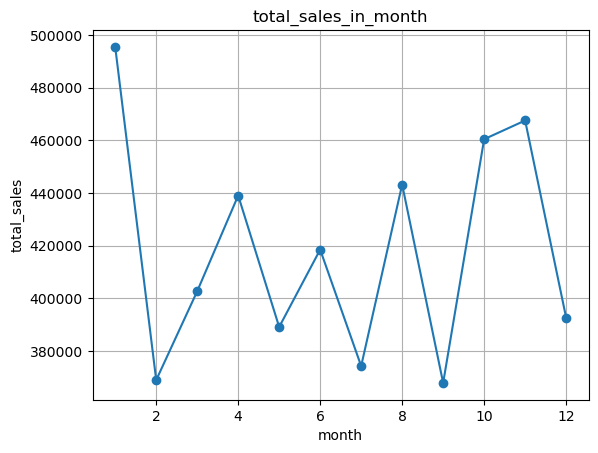

In [21]:
# data visualization 
# sales trend (line chart)

data = df.groupby("month")["sales_amount"].sum()

x = data.index
y = data.values

plt.plot(x , y, marker = "o")
plt.xlabel("month")
plt.ylabel("total_sales")
plt.title("total_sales_in_month")
plt.grid(True)
plt.show()

# insight - “The line chart shows fluctuations in monthly sales, 
#           with peak performance in January, October, and November,
#           while lower sales are observed in February, July, and September. 


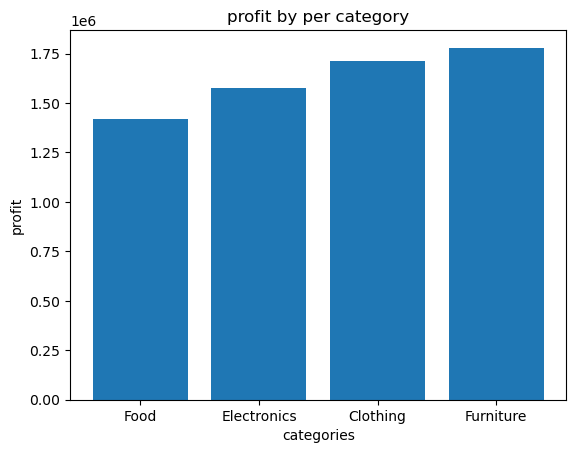

In [22]:
# profit by category

data = df.groupby("product_category")["total_profit"].sum().sort_values()

x = data.index
y = data.values

plt.bar(x , y)
plt.xlabel("categories")
plt.ylabel("profit")
plt.title("profit by per category")
plt.show()


# insight - Furniture is the most profitable product category, 
#           followed by Clothing and Electronics, while Food generates the lowest profit. 


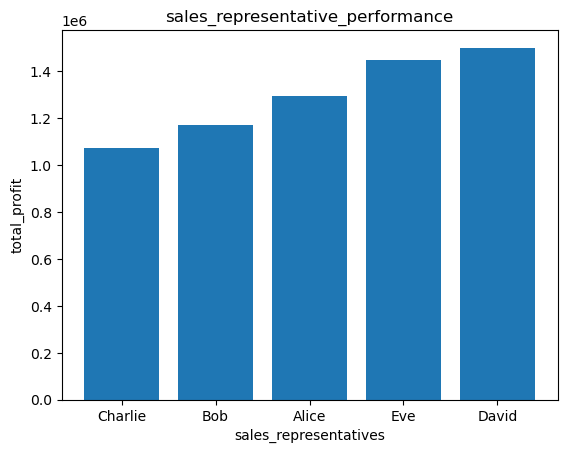

In [23]:
# sales representative performanace

data = df.groupby("sales_rep")["total_profit"].sum().sort_values()

x = data.index
y = data.values

plt.bar(x, y )
plt.title("sales_representative_performance")
plt.xlabel("sales_representatives")
plt.ylabel("total_profit")
plt.show()

# insight - David is the top-performing sales representative in terms of total profit, 
#           followed by Eve and Alice, while Charlie shows the lowest performance. 


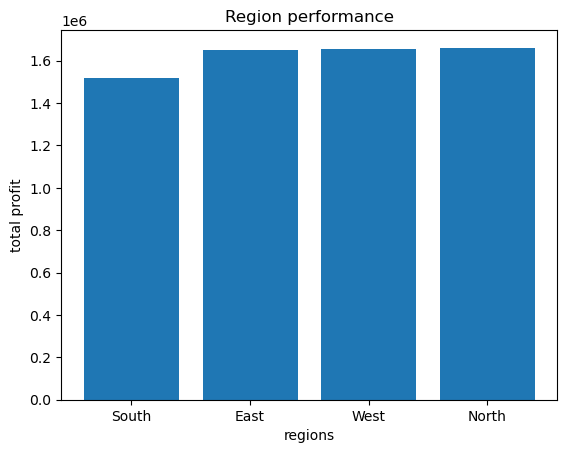

In [24]:
# Region performance 

data = df.groupby("region")["total_profit"].sum().sort_values()

x = data.index
y = data.values

plt.bar(x , y)
plt.title("Region performance")
plt.xlabel("regions")
plt.ylabel("total profit")
plt.show()

# insight - The North region generates the highest profit, 
#           followed closely by West and East, while the South region shows comparatively lower performance.


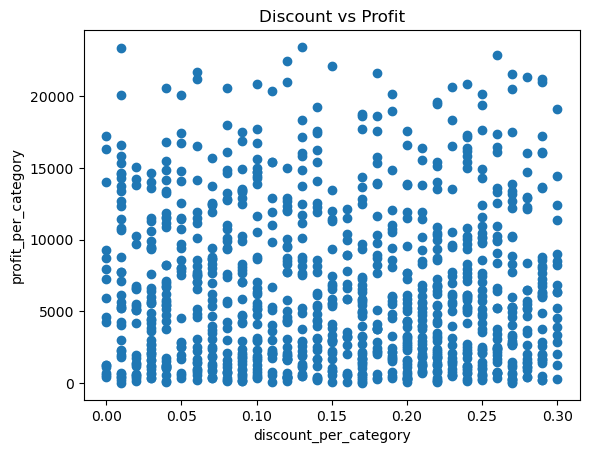

In [26]:
# Discount vs Profit


x = df["discount"]
y = df["total_profit"]

plt.scatter(x , y)
plt.title("Discount vs Profit")
plt.xlabel("discount_per_category")
plt.ylabel("profit_per_category")
plt.show()

# insight - The scatter plot shows a scattered distribution of data points,
#           indicating no strong relationship between discount and total profit. 


In [27]:
#📌   Key Insights


#  *   Furniture is the most profitable product category, making it a key revenue driver for the business.
#  *   The North region generates the highest profit, while the South region shows comparatively
#      lower performance, though overall regional performance is fairly balanced.
#  *   Sales representatives show varied performance, with David leading in total profit and Charlie 
#      contributing the least.
#  *   Discount analysis reveals no strong positive relationship between discount and profit, indicating that higher discounts
#      do not guarantee higher profitability.
#  *   Monthly sales analysis shows fluctuations, with peak performance in January, October, and November, 
#      suggesting possible seasonal demand patterns.
#  *   Customer behavior analysis shows that new customers prefer Bank Transfer, while returning customers 
#      prefer Credit Card, with overall balanced payment preferences.
#  *   Outlier analysis indicates the presence of high-profit transactions, which are likely genuine and 
#      important for business insights.


In [28]:
# 💡  Business Recommendations

#  *  Focus on promoting high-profit categories like Furniture to maximize revenue.
#  *  Improve strategies in the South region to enhance overall regional performance.
#  *  Analyze top-performing sales representatives’ strategies (e.g., David) and apply them to improve lower-performing team members.
#  *  Optimize discount strategies to avoid excessive discounting that reduces profitability.
#  *  Increase marketing and inventory planning during high-performing months to maximize sales opportunities.
#  *  Maintain multiple payment options to support diverse customer preferences.



In [29]:
# 📝 Conclusion


#     This project analyzed sales data to uncover key insights related to profitability, customer behavior, and 
#     business performance. The analysis highlighted important factors such as product category performance, 
#     regional trends, discount impact, and seasonal sales patterns. These insights can help the business make 
#     data-driven decisions to improve revenue, optimize strategies, and enhance overall performance.


